# Power analysis attack on AES with custom SBox 

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys
sys.path.append( '../AES_python' )
sys.path.append( '../sca_python' )
sys.path.append( '../x-heep' )

import readFirmware

ports = list(port_list.comports())
for p in ports:
    print (p)

# An already generated bitstream is available in the repository at the path:
bitstream = r"../../hw/fpga/bitstream/xheep/cw305_top.bit"
# Alternatively, you can generate the bitstream yourself by running the following command:
#   make vivado-fpga
# and the generated bitstream will be available at the path:
#bitstream = r"../../hw/vendor/cw305-heep/build/polito_cw305_heep_cw305_heep_0.0.1/cw305-vivado/polito_cw305_heep_cw305_heep_0.0.1.runs/impl_1/cw305_top.bit"
# Note that this folder is temporary and will be deleted when you run the 'make clean' command.

verilog_defines = r"../../hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v"

"""
Available S-boxes:
    sbox_rijandael (default AES S-Box)
    sbox_freyre_1
    sbox_freyre_2
    sbox_freyre_3
    sbox_hussain_6
    sbox_ozkaynak_1
    sbox_azam_1
    sbox_azam_2
    sbox_azam_3
"""
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")
project_file = "../../build/xheep_test/xheep_test_CW305_"+sbox_id+".cwp" #TODO: remove the project file and use just the traces

# To run a generic compiled firmware, you can use the following path:
#firmware = r"../../hw/vendor/cw305-heep/sw/build/main.hex"

# To run AES firmware with a specific S-box, you can use the following path:
firmware = r"../x-heep/AES_Sbox_firmware/main_"+sbox_id+".hex"

/dev/ttyS4 - n/a
/dev/ttyS31 - n/a
/dev/ttyS30 - n/a
/dev/ttyS29 - n/a
/dev/ttyS28 - n/a
/dev/ttyS27 - n/a
/dev/ttyS26 - n/a
/dev/ttyS25 - n/a
/dev/ttyS24 - n/a
/dev/ttyS23 - n/a
/dev/ttyS22 - n/a
/dev/ttyS21 - n/a
/dev/ttyS20 - n/a
/dev/ttyS19 - n/a
/dev/ttyS18 - n/a
/dev/ttyS17 - n/a
/dev/ttyS16 - n/a
/dev/ttyS15 - n/a
/dev/ttyS14 - n/a
/dev/ttyS13 - n/a
/dev/ttyS12 - n/a
/dev/ttyS11 - n/a
/dev/ttyS10 - n/a
/dev/ttyS9 - n/a
/dev/ttyS8 - n/a
/dev/ttyS7 - n/a
/dev/ttyS6 - n/a
/dev/ttyS5 - n/a
/dev/ttyS3 - n/a
/dev/ttyS2 - n/a
/dev/ttyS1 - n/a
/dev/ttyS0 - n/a
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART


In [14]:
print("bitstream: ", bitstream)
print("firmware: ", firmware)
print("verilog_defines: ", verilog_defines)
print("project_file: ", project_file)

bitstream:  ../../hw/fpga/bitstream/xheep/cw305_top.bit
firmware:  ../x-heep/AES_Sbox_firmware/main_rijandael.hex
verilog_defines:  ../../hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v
project_file:  ../../build/xheep_test/xheep_test_CW305_rijandael.cwp


In [3]:
from picoscope import ps5000a
import chipwhisperer as cw
import time
from picosdk.discover import find_all_units

import os
os.system("pip list | grep chipwhisperer")



chipwhisperer                     5.7.0


You should consider upgrading via the '/home/lorenzo_capobianco/.pyenv/versions/3.9.5/bin/python3.9 -m pip install --upgrade pip' command.


0

## Picoscope and CW305 initialization

In [4]:
from pico_api import PS5000aWrapper

try:
    # Initialize picoscope
    ps = PS5000aWrapper()
    ps.get_unitInfo()
    #ps.scope_setup(obs_time=1E-3, nSamples=400000) # 1ms time window, 400k samples which results in 2 ns sampling interval. Much higher than the 10 MHz clock frequency for X-HEEP.
    ps.scope_setup(obs_time=1E-4, nSamples=4000) # 0.1ms time window, 4k samples which results in ~25 ns sampling interval.


    # Initialize CW305 with required parameters. More in detail:
    # ps: picoscope object
    # cw.targets.CW305: target device
    # bsfile: bitstream file
    # force: force programming
    # slurp: used to get the device verilog defines for the register addresses
    # defines_files: verilog defines file path.
    cw305 = cw.target(None, cw.targets.CW305, bsfile=bitstream, force=True, slurp=True, defines_files=[verilog_defines])
    cw305.vccint_set(1.0)
    cw305.pll.pll_enable_set(True)             # enable PLL chip
    cw305.pll.pll_outenable_set(False, 0)      # disable PLL 0
    cw305.pll.pll_outenable_set(True, 1)       # enable PLL 1
    cw305.pll.pll_outenable_set(False, 2)      # disable PLL 2
    cw305.pll.pll_outfreq_set(10E6, 1)         # PLL1 frequency set to 10 MHz
    # Disable usb_clock. Optional, but reduces power trace noise
    cw305.clkusbautooff = True
    # 1 ms is plenty idling time 
    cw305.clksleeptime = 1

    # Set the clock source writing the corresponding register
    cw305.fpga_write(cw305.REG_CLKSETTINGS, data=bytearray([0x01]))
    # DEBUG
    # print("FPGA CLKSETTINGS REGISTER: ", cw305.fpga_read(cw305.REG_CLKSETTINGS, 1)[::-1])

    # Load firmware
    readFirmware.readFirmware(cw305, firmware)
    
except ModuleNotFoundError as e:
    print(e)

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.7.5057
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : KU687/0175
CalDate                       : 26Apr23
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0

Firmware file '../x-heep/AES_Sbox_firmware/main_aes.hex' found. Loading firmware...


...Firmware loaded. Setting boot exit loop flag...


...Done



In [5]:
print(ps.get_scopeSettings())
print()
print("Sampling Interval: ", ps.get_samplingInterval(), "s")

Nsamples :  4167
Sampling interval = %f us 2.4e-08
Channel A settings:  Channel A: Range = 50mV, AC coupling, 20 MHz BW limit
Channel B settings:  Channel B: Range = 10V, DC coupling, trigger
None

Sampling Interval:  2.4e-08 s


## Online phase : AES power traces capture

In [6]:
from tqdm.notebook import tnrange
#import chipwhisperer as cw
from chipwhisperer.common.traces import Trace
from Crypto.Cipher import AES
from AES_golden import AES_golden_model

project = cw.create_project(project_file, overwrite=True)

# Initialize key and plain text
key  = [ 0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6, 0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c ]
# key  = [ 0x3c, 0x8f, 0x26, 0x27, 0x39, 0xbf, 0xe3, 0xb1, 0xbc, 0x08, 0x26, 0x99, 0x1a, 0xd0, 0x52, 0x4d ]
text = [ 0x6e, 0xc1, 0x53, 0x9c, 0xfb, 0xe7, 0xf6, 0x18, 0x92, 0xac, 0x19, 0x87, 0xf5, 0x94, 0xe1, 0x2b ]

# Each element of the key is converted to a 2-digit hex string 
formatted_key = ''.join(format(el, '02x') for el in key)
print("Key: ", [ hex(subkey) for subkey in key])

# Initialize the AES software emulated cipher
cipher = AES_golden_model()

# Number of traces to capture
N = 5000

for i in tnrange(N, desc='Capturing traces'):
    # Run the target
    ps.runBlock()
    time.sleep(0.05)

    # Write 8 to the status register to trigger the program execution and the scope acquisition
    cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))

    ps.waitReady()

    # Get captured trace 
    data = ps.getDataV()

    trace = Trace(np.array(data), text, cipher.encrypt(formatted_key, text, tested_sbox), key)
    project.traces.append(trace)
    #print("Cipertext: ", [ hex(subkey) for subkey in cipher.encrypt(formatted_key, text, tested_sbox)])
    
    # Update the plain text as the previous chipertext
    text = cipher.encrypt(formatted_key, text, tested_sbox)

    time.sleep(1E-3) # 1 ms
    # Reset the status register to reload the program execution and the scope acquisition
    cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

project.save()
project.close()
# Disconnect CW305 and picoscope
cw305.dis()
ps.dis()

Key:  ['0x2b', '0x7e', '0x15', '0x16', '0x28', '0xae', '0xd2', '0xa6', '0xab', '0xf7', '0x15', '0x88', '0x9', '0xcf', '0x4f', '0x3c']


Capturing traces:   0%|          | 0/5000 [00:00<?, ?it/s]

## Offline phase : attack on captured traces

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
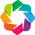

In [7]:
import os
import chipwhisperer.analyzer as cwa
import chipwhisperer as cw
import holoviews as hv
hv.extension('bokeh')
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
from analyzer.attack.aes.key_schedule import key_schedule_rounds
from analyzer.utils.sca_plots import sca_plot

sca_plt = sca_plot()
project = cw.open_project(project_file)

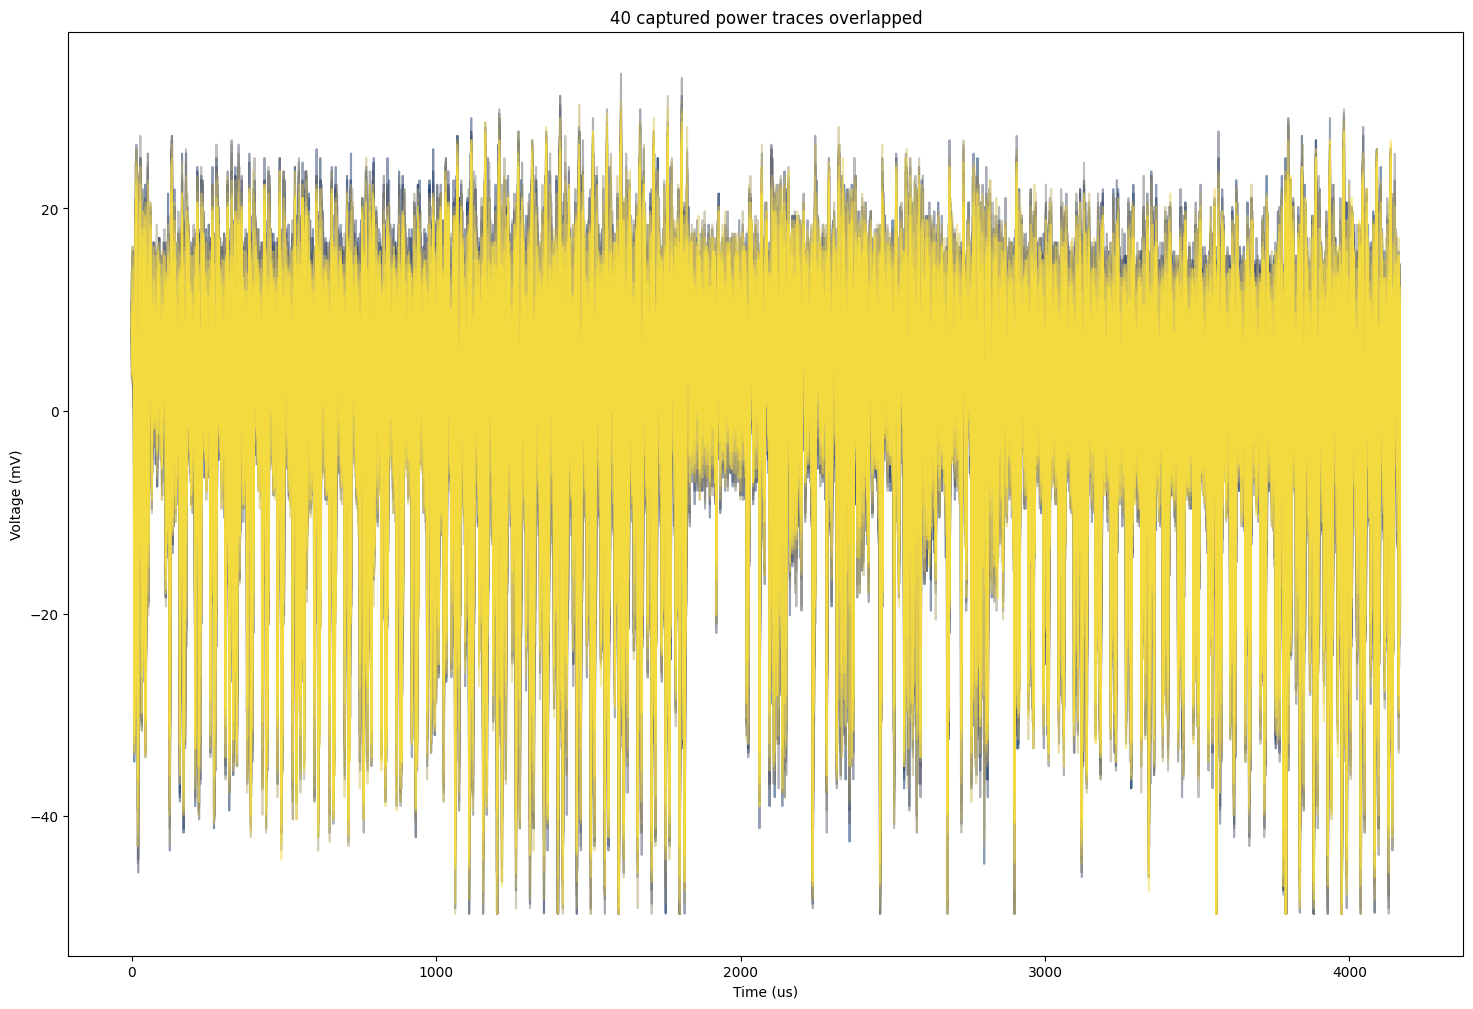

In [8]:
power_plt = sca_plt.power_traces_overlapped(ps.get_samplingInterval(), project.waves, finish=len(project.waves[0]))
power_plt.show()
# Ensure the Graphs directory exists
# os.makedirs("Graphs", exist_ok=True)
# power_plt.savefig("Graphs/power_traces_overlapped"+tested_sbox+".png")

In [9]:
cw.plot(project.waves[0])

/home/lorenzo_capobianco/.pyenv/versions/3.9.5/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/home/lorenzo_capobianco/.pyenv/versions/3.9.5/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Curve   [x]   (y)

### SNR evaluation : detect leakage points

In [15]:
#leak_model = cwa.leakage_models.sbox_output
#project.traces.extend(project.traces)

# First round sbox output snr calculation
#leak_model = cwa.leakage_models.sbox_output
leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(tested_sbox)
snr_fr = cwa.calculate_snr(project.traces, leak_model=leak_model, db=False)
curve = hv.Curve(snr_fr).opts(height=600, width=600, color='orange', alpha=0.5)
# Last round state diff snr calculation
# leak_model = AES128SboxResistantLeakageModels().LastroundStateDiff_ModifiedSbox(tested_sbox)
# snr_lr = cwa.calculate_snr(project.traces, leak_model=leak_model, db=False)
# curve *= hv.Curve(snr_lr).opts(height=600, width=600, color='blue', alpha=0.5)

#curve.opts(width=900, height=600, show_legend=True, legend_position='right', xlabel='Sample', ylabel='SNR', title="SNR in time") 
curve.opts(width=900, height=600, show_legend=True, xlabel='Sample', ylabel='SNR', title="SNR in time") 


:Curve   [x]   (y)

1. Aggiungere calcolo TVLA 

### Hamming distance attack : state difference leakage model on last round

In [16]:
#leak_model = cwa.leakage_models.sbox_output
leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(tested_sbox)
attack = cwa.cpa(project, leak_model)
#cb = cwa.get_jupyter_callback(attack)
results = attack.run(cwa.get_jupyter_callback(attack, 10))
#print(results.best_guesses())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PGE=,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,2B0.332,7E0.299,150.311,160.251,280.392,AE0.333,D20.338,A60.280,AB0.425,F70.385,150.376,880.291,090.443,CF0.427,4F0.407,3C0.363
1,DE0.124,EC0.113,870.128,E30.106,DD0.146,5B0.126,270.134,3F0.125,5E0.172,020.142,570.161,550.136,900.180,3A0.145,240.167,0E0.155
2,F90.119,410.102,E30.122,C90.101,B10.135,E30.114,E00.122,E40.121,E60.143,6E0.138,E00.147,B70.124,620.170,560.144,F20.165,A50.133
3,840.118,4E0.100,570.119,4F0.101,6A0.128,070.112,E90.117,340.116,FD0.136,C70.123,650.136,CA0.120,360.162,820.142,D60.156,810.131
4,1D0.115,A30.100,FE0.113,840.101,950.127,370.106,CD0.114,1B0.116,990.135,5E0.117,870.135,7D0.117,370.146,520.142,BA0.147,1F0.128
5,DD0.115,E70.098,C70.110,290.099,900.120,330.105,4B0.114,530.116,160.131,E40.116,B20.133,1A0.114,FC0.143,D90.136,A30.147,360.121
6,600.114,560.095,920.106,CB0.098,8B0.113,F90.102,ED0.110,E60.109,320.129,B50.115,110.132,8C0.109,430.142,FF0.124,740.136,030.120
7,440.114,680.095,A80.106,AE0.097,540.108,9E0.101,6F0.109,990.107,020.128,4A0.114,8C0.132,BA0.108,4B0.139,F00.122,710.136,0C0.120
8,D70.113,B40.092,DE0.103,A70.096,1A0.108,090.097,D80.109,580.102,610.126,4C0.113,2E0.128,B30.107,440.138,C40.119,2A0.133,FB0.117


In [43]:
# Recover key
recv_firstroundkey = [kguess[0][0] for kguess in results.find_maximums()]
recv_key = key_schedule_rounds(recv_firstroundkey, 0, 0, tested_sbox)
print("Recovered key: ", [hex(subkey) for subkey in recv_key])
key=list(project.keys[0])
assert (key == recv_key), "Failed to recover encryption key!\nGot {}\nExp {}\n".format(recv_key, key)
print("Key recovery : Success!")

Recovered key:  ['0x2b', '0x7e', '0x15', '0x16', '0x28', '0xae', '0xd2', '0xa6', '0xab', '0xf7', '0x15', '0x88', '0x9', '0xcf', '0x4f', '0x3c']
Key recovery : Success!


2. Grafico PGE
3. Grafico correlation

## Graphical Results : interpreting the attack

In [44]:
import holoviews as hv
from holoviews.operation.datashader import datashade, shade, dynspread, rasterize
from holoviews.operation import decimate
import pandas as pd, numpy as np
plot_data = cwa.analyzer_plots(results)

### - Calculated correlation at each point in time for the correct key

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
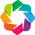

/home/lorenzo_capobianco/.pyenv/versions/3.9.5/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/home/lorenzo_capobianco/.pyenv/versions/3.9.5/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.I      :Curve   [Sample]   (0)
   .Curve.II     :Curve   [index]   (1)
   .Curve.III    :Curve   [index]   (2)
   .Curve.IV     :Curve   [index]   (3)
   .Curve.V      :Curve   [index]   (4)
   .Curve.VI     :Curve   [index]   (5)
   .Curve.VII    :Curve   [index]   (6)
   .Curve.VIII   :Curve   [index]   (7)
   .Curve.IX     :Curve   [index]   (8)
   .Curve.X      :Curve   [index]   (9)
   .Curve.XI     :Curve   [index]   (10)
   .Curve.XII    :Curve   [index]   (11)
   .Curve.XIII   :Curve   [index]   (12)
   .Curve.XIV    :Curve   [index]   (13)
   .Curve.XV     :Curve   [index]   (14)
   .Curve.XVI    :Curve   [index]   (15)
   .Curve.XVII   :Curve   [index]   (0)
   .Curve.XVIII  :Curve   [index]   (1)
   .Curve.XIX    :Curve   [index]   (2)
   .Curve.XX     :Curve   [index]   (3)
   .Curve.XXI    :Curve   [index]   (4)
   .Curve.XXII   :Curve   [index]   (5)
   .Curve.XXIII  :Curve   [index]   (6)
   .Curve.XXIV   :Curve   [index]   (7)
   .Curve.XXV    :Curve   [index]   (8)
   .Curve.XXVI   :Curve   [index]   (9)
   .Curve.XXVII  :Curve   [index]   (10)
   .Curve.XXVIII :Curve   [index]   (11)
   .Curve.XXIX   :Curve   [index]   (12)
   .Curve.XXX    :Curve   [index]   (13)
   .Curve.XXXI   :Curve   [index]   (14)
   .Curve.XXXII  :Curve   [index]   (15)

In [45]:
def byte_to_color(idx):
    return hv.Palette.colormaps['Category20'](idx/16.0)

a = []
b = []
hv.extension('bokeh')

# display the calculated correlation at each point in time for the correct key
for key_byte in range(0, 16):
    data = plot_data.output_vs_time(key_byte)
    a.append(np.array(data[1]))
    b.append(np.array(data[2]))
    b.append(np.array(data[3]))

pda = pd.DataFrame(a).transpose().rename(str, axis='columns')
pdb = pd.DataFrame(b).transpose().rename(str, axis='columns')   
curve = hv.Curve(pdb['0'], "Sample").options(color='black')

for key_byte in range(1, 16):
    curve *= hv.Curve(pdb[str(key_byte)]).options(color=byte_to_color(key_byte))

for key_byte in range(0, 16):
    curve *= hv.Curve(pda[str(key_byte)]).options(color=byte_to_color(key_byte))
curve.opts(width=900, height=600)
#decimate(curve.opts(width=900, height=600)) 

#### - PGE vs Traces

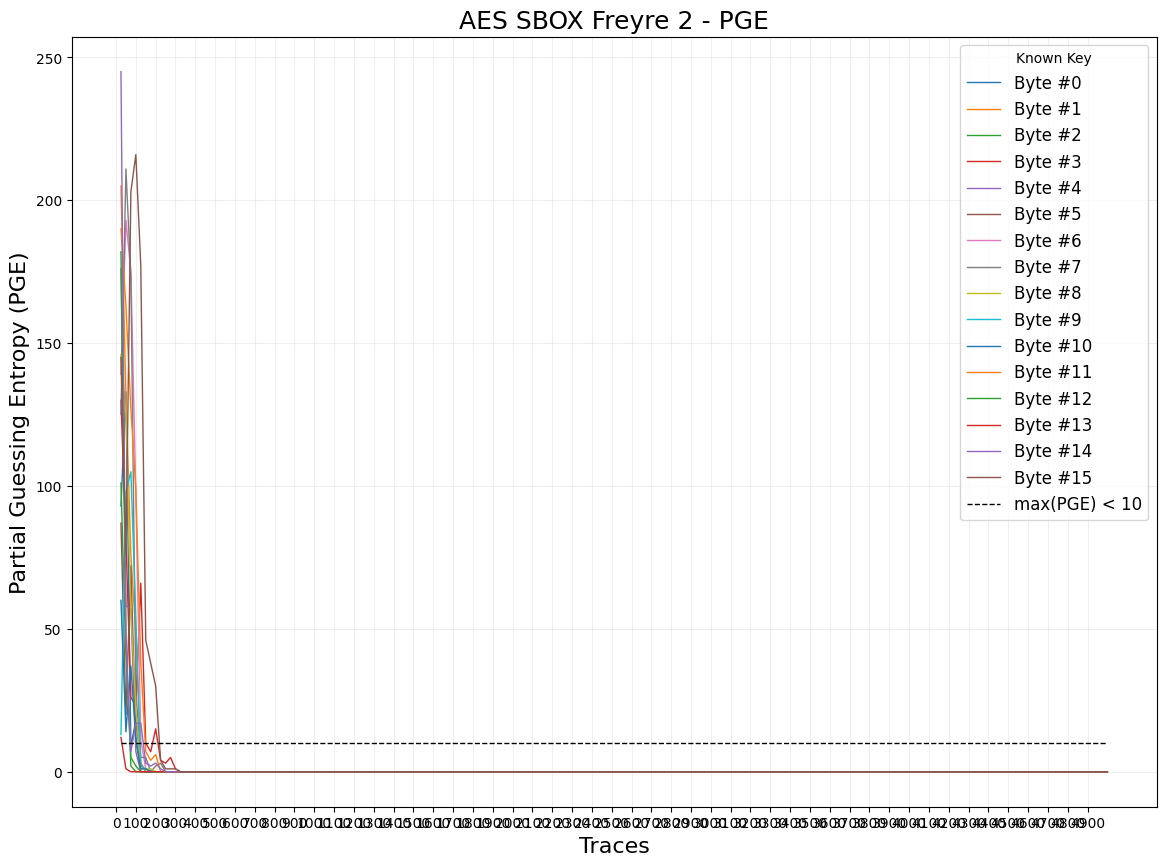

In [47]:
import numpy as np
import matplotlib.pyplot as plt
"""
Plots the PGE trends for all the 16 correct key guesses with matplotlib
"""

pges = [plot_data.pge_vs_trace(i) for i,_ in enumerate(key)]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=[14,10])
plt.grid(which='major', axis='both', alpha=0.2)

x_axis = plot_data.pge_vs_trace(0)[0]
step = 100
for i, bnum in enumerate(key):
    plt.plot(pges[i][0], pges[i][1], linewidth=1, label=f"Byte #{i}")
plt.plot(pges[i][0], [10 for _ in range(len(pges[i][0]))], linewidth=1, linestyle="dashed",  color="black", label=f"max(PGE) < {10}")
    
plt.legend(title=f"Known Key", fontsize=12, loc="upper right")
plt.title("AES SBOX Freyre 2 - PGE", fontsize=18)
ax1.set_xticks(range(0, x_axis[-1], step))
# clip_min_y = 0
# clip_max_y = 300
# ax1.set_yticks(list(range(clip_min_y, clip_max_y+1, 10)))
ax1.set_ylabel('Partial Guessing Entropy (PGE)', fontsize=16)
ax1.set_xlabel('Traces', fontsize=16)
plt.show()
#plt.savefig("Graphs/PGE_hussain_6.png")
plt.close(fig)

In [48]:
ret = plot_data.pge_vs_trace(0)
curve = hv.Curve((ret[0], ret[1], "Traces Used in Calculation", "Partial Guessing Entropy of Byte"))

for bnum in range(1,16):
    ret = plot_data.pge_vs_trace(bnum)
    curve *= hv.Curve((ret[0], ret[1])).opts(color=byte_to_color(bnum))
curve.opts(width=900, height=600)

:Overlay
   .Curve.I    :Curve   [x]   (y)
   .Curve.II   :Curve   [x]   (y)
   .Curve.III  :Curve   [x]   (y)
   .Curve.IV   :Curve   [x]   (y)
   .Curve.V    :Curve   [x]   (y)
   .Curve.VI   :Curve   [x]   (y)
   .Curve.VII  :Curve   [x]   (y)
   .Curve.VIII :Curve   [x]   (y)
   .Curve.IX   :Curve   [x]   (y)
   .Curve.X    :Curve   [x]   (y)
   .Curve.XI   :Curve   [x]   (y)
   .Curve.XII  :Curve   [x]   (y)
   .Curve.XIII :Curve   [x]   (y)
   .Curve.XIV  :Curve   [x]   (y)
   .Curve.XV   :Curve   [x]   (y)
   .Curve.XVI  :Curve   [x]   (y)

#### Correlation vs Traces with matplot lib

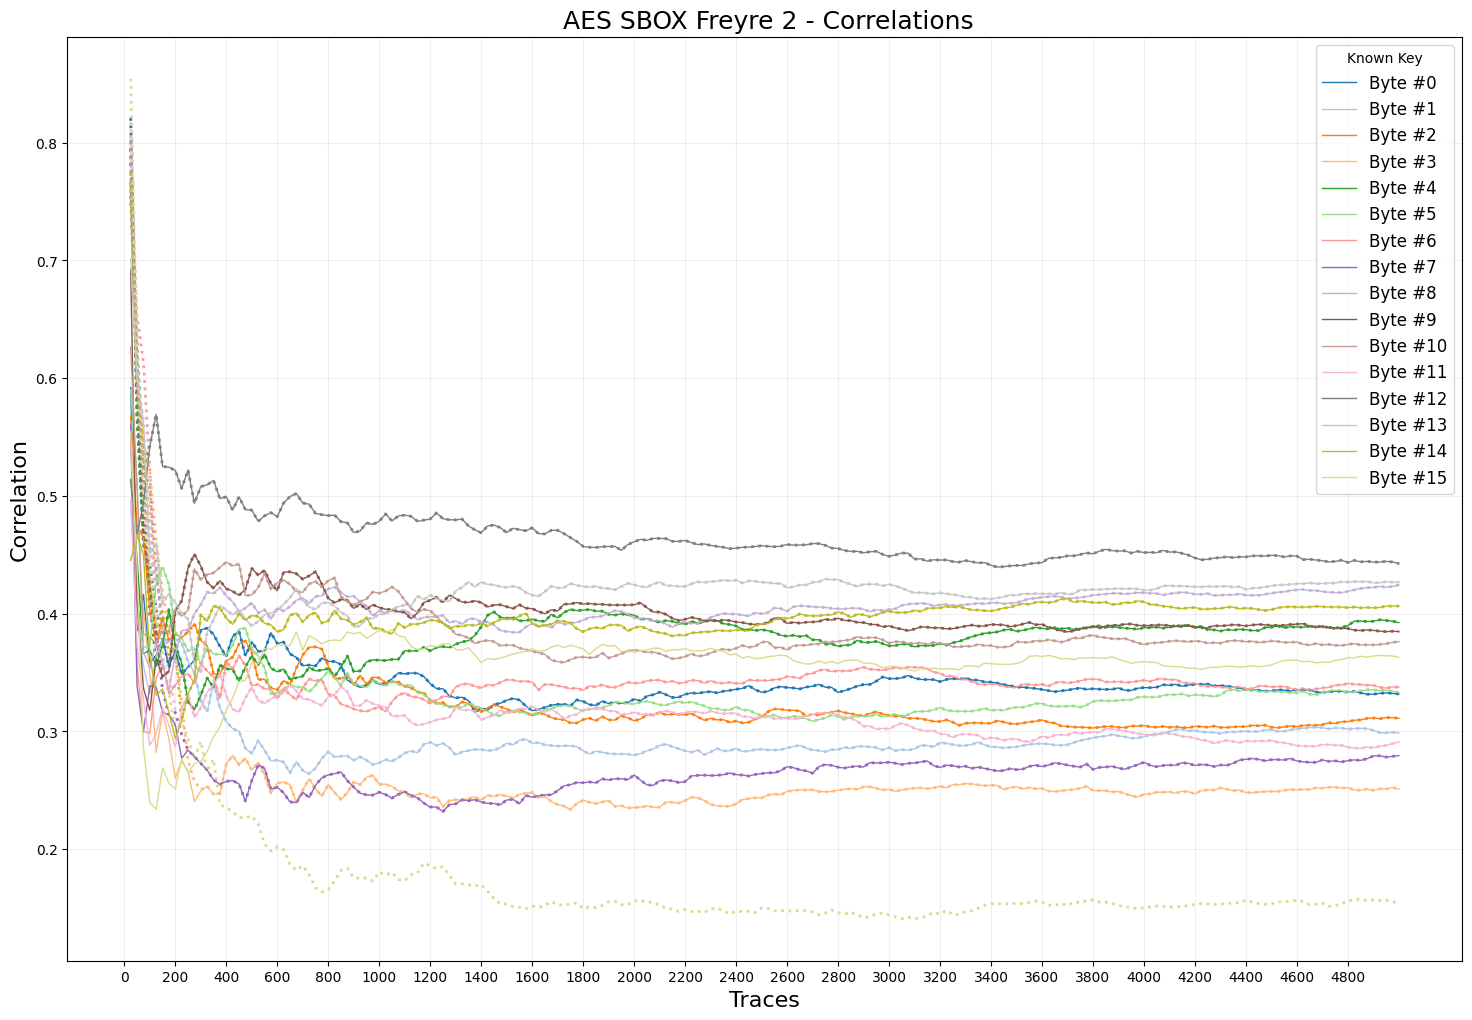

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def byte_to_color(idx):
    return hv.Palette.colormaps['Category20'](idx/16.0)
"""
Plots the various correlations of both the correct key guesses and the wrong ones
"""
# 16 subkeyCW305_leakage_model
bnum_it = range(16)

fig, ax1 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=[18,12])
plt.grid(which='major', axis='both', alpha=0.2)

# Plot correlation trends of wrong key guesses (
for bnum in bnum_it:
    data = np.array(plot_data.corr_vs_trace(bnum)[1])
    xrangelist = plot_data.corr_vs_trace(bnum)[0]
    wrong_results = data[[i != key for i in range(256)]]
    ax1.plot(xrangelist, np.amax(wrong_results, 0), linewidth=2, linestyle ="dotted", color=byte_to_color(bnum))

# Plot correct key_guesses on top of wrong ones
for bnum in bnum_it:
    data = np.array(plot_data.corr_vs_trace(bnum)[1])
    xrangelist = plot_data.corr_vs_trace(bnum)[0]
    key = results.known_key[bnum]
    wrong_results = data[[i != key for i in range(256)]]
    ax1.plot(xrangelist, data[key], linewidth=1, label=f"Byte #{bnum}", color=byte_to_color(bnum))


ax1.legend(title=f"Known Key", fontsize=12, loc="upper right")
plt.title(" AES SBOX Freyre 2 - Correlations", fontsize=18)

step = 200
ax1.set_xticks(range(0, xrangelist[-1], step))
ax1.set_ylabel('Correlation', fontsize=16)
ax1.set_xlabel('Traces', fontsize=16)

plt.show()
#plt.savefig("Graphs/correlations_Freyre_2.png")
plt.close(fig)